In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('/content/Dataset.csv')

In [3]:
from google.colab import drive


In [4]:
df.head(2).T

,0,1
Timestamp,2025/11/27 10:07:46 PM GMT+6,2025/11/27 10:08:05 PM GMT+6
1. Age: _______ (years),27,25
2. Gender:,Female,Male
3. Relationship status:,Single,In a relationship/ Married
4. Current primary occupation:,Employee,Student
5. Primary work / activity setting:,Government / Semi-governmentCorporate / Private,NaN
6. Do you currently use social media?,Yes,Yes
7. Which social media platforms do you use regularly? (tick all that apply),Facebook;Instagram;YouTube,Facebook;Instagram;YouTube
8. Average time spent on social media per day:,More than 4 hours,More than 4 hours
9. How often do you use social media without a specific purpose (mindless browsing)?,Often,Often


In [5]:

df.drop(['Timestamp'], inplace = True, axis = 1)

df.drop(['23. Attention check: To ensure data quality, please select 3 for this question.'], inplace = True, axis = 1)

df.drop(columns=["24. Optional: Anything else you'd like to share about your social media use and work–life balance?"], inplace=True)

In [6]:
col_names_dict = {
    '1. Age: _______ (years)': 'age',
    '2. Gender:': 'gender',
    '3. Relationship status:': 'relationship_status',
    '4. Current primary occupation:': 'occupation_status',
    '5. Primary work / activity setting:': 'org_affiliation',

    ' 6. Do you currently use social media?': 'uses_social_media',
    '7. Which social media platforms do you use regularly? (tick all that apply)': 'platforms_used',
    '8. Average time spent on social media per day:': 'daily_time_spent',

    '9. How often do you use social media without a specific purpose (mindless browsing)?': 'mindless_use_freq',
    '10. How often do social media notifications or content distract you during important tasks (work, study, chores etc.)?': 'distraction_when_busy_freq',
    '11. When you haven’t used social media for a while, how restless or uneasy do you feel?': 'restless_without_sm',

    '12. What aspects of social media distract you the most? (tick all that apply)': 'top_distraction_sources',
    '13. On a scale of 1–5, how strongly do these distractions affect your ability to focus?': 'distraction_impact',
    '14. How often do you find it difficult to concentrate on tasks?( Using Social Media)': 'concentration_difficulty_freq',

    '15. On a typical day, how productive do you feel?': 'daily_productivity',
    '16. How often do you feel that social media negatively affects your productivity or performance?': 'sm_negative_impact_freq',

    '17. How often do you compare yourself with others on social media?': 'social_comparison_freq',
    '18. Overall, how do these comparisons make you feel?': 'comparison_feelings',
    '19. How often do you seek validation on social media (likes, comments, reactions)?': 'validation_seeking_freq',

    '20. Over the past two weeks, how often have you felt depressed, upset, or unusually sad?': 'low_mood_freq',
    '21. How often does your motivation or interest in daily activities fluctuate?': 'interest_fluctuation_freq',
    '22. How often do you experience sleep-related issues (difficulty falling or staying asleep)?': 'sleep_issues_freq',
}

In [7]:
df.columns

Index(['1. Age: _______ (years)', '2. Gender:', '3. Relationship status:',
       '4. Current primary occupation:', '5. Primary work / activity setting:',
       ' 6. Do you currently use social media?',
       '7. Which social media platforms do you use regularly? (tick all that apply)',
       '8. Average time spent on social media per day:',
       '9. How often do you use social media without a specific purpose (mindless browsing)?',
       '10. How often do social media notifications or content distract you during important tasks (work, study, chores etc.)?',
       '11. When you haven’t used social media for a while, how restless or uneasy do you feel?',
       '12. What aspects of social media distract you the most? (tick all that apply)',
       '13. On a scale of 1–5, how strongly do these distractions affect your ability to focus?',
       '14. How often do you find it difficult to concentrate on tasks?( Using Social Media)',
       '15. On a typical day, how productive do yo

In [8]:
df.shape

df.rename(columns=col_names_dict, inplace=True)
df.head(2).T

,0,1
age,27,25
gender,Female,Male
relationship_status,Single,In a relationship/ Married
occupation_status,Employee,Student
org_affiliation,Government / Semi-governmentCorporate / Private,NaN
uses_social_media,Yes,Yes
platforms_used,Facebook;Instagram;YouTube,Facebook;Instagram;YouTube
daily_time_spent,More than 4 hours,More than 4 hours
mindless_use_freq,Often,Often
distraction_when_busy_freq,Rarely,Always


In [9]:
df["age_num"] = pd.to_numeric(df["age"], errors="coerce")

# Drop rows where age is missing/invalid
df = df.dropna(subset=["age_num"]).copy()

# Make age integer if you want
df["age"] = df["age_num"].astype(int)

# Remove helper column (optional)
df.drop(columns=["age_num"], inplace=True)

# Reset index for neatness (optional)
df.reset_index(drop=True, inplace=True)

df.shape

(1003, 22)

In [10]:
titles = list(df.columns)

In [11]:
titles

['age',
 'gender',
 'relationship_status',
 'occupation_status',
 'org_affiliation',
 'uses_social_media',
 'platforms_used',
 'daily_time_spent',
 'mindless_use_freq',
 'distraction_when_busy_freq',
 'restless_without_sm',
 'top_distraction_sources',
 'distraction_impact',
 'concentration_difficulty_freq',
 'daily_productivity',
 'sm_negative_impact_freq',
 'social_comparison_freq',
 'comparison_feelings',
 'validation_seeking_freq',
 'low_mood_freq',
 'interest_fluctuation_freq',
 'sleep_issues_freq']

In [12]:
df.isnull().sum()

,0
age,0
gender,0
relationship_status,0
occupation_status,0
org_affiliation,469
uses_social_media,0
platforms_used,2
daily_time_spent,9
mindless_use_freq,0
distraction_when_busy_freq,0


In [13]:
print([f"Nan values in: {(element, value)}" for (element, value) in zip(df.isnull().sum().index, df.isnull().sum()) if value > 0])

f"Percent NaN = {df.org_affiliation.isnull().sum()/len(df.org_affiliation)*100:0.2f} %"

df.org_affiliation.fillna(df['org_affiliation'].value_counts().index[0], inplace=True)

f"Percent NaN = {df.platforms_used.isnull().sum()/len(df.platforms_used)*100:0.2f} %"

df.platforms_used.fillna(df['platforms_used'].value_counts().index[0], inplace=True)

f"Percent NaN = {df.daily_time_spent.isnull().sum()/len(df.daily_time_spent)*100:0.2f} %"

df.daily_time_spent.fillna(df['daily_time_spent'].value_counts().index[0], inplace=True)

f"Percent NaN = {df.sleep_issues_freq.isnull().sum()/len(df.sleep_issues_freq)*100:0.2f} %"

df.sleep_issues_freq.fillna(df['sleep_issues_freq'].value_counts().index[0], inplace=True)

["Nan values in: ('org_affiliation', 469)", "Nan values in: ('platforms_used', 2)", "Nan values in: ('daily_time_spent', 9)", "Nan values in: ('sleep_issues_freq', 5)"]


/tmp/ipykernel_1125/33476795.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.org_affiliation.fillna(df['org_affiliation'].value_counts().index[0], inplace=True)
/tmp/ipykernel_1125/33476795.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].

In [14]:
df.isnull().sum()

,0
age,0
gender,0
relationship_status,0
occupation_status,0
org_affiliation,0
uses_social_media,0
platforms_used,0
daily_time_spent,0
mindless_use_freq,0
distraction_when_busy_freq,0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1003 entries, 0 to 1002
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1003 non-null   int64  
 1   gender                         1003 non-null   object 
 2   relationship_status            1003 non-null   object 
 3   occupation_status              1003 non-null   object 
 4   org_affiliation                1003 non-null   object 
 5   uses_social_media              1003 non-null   object 
 6   platforms_used                 1003 non-null   object 
 7   daily_time_spent               1003 non-null   object 
 8   mindless_use_freq              1003 non-null   object 
 9   distraction_when_busy_freq     1003 non-null   object 
 10  restless_without_sm            1003 non-null   int64  
 11  top_distraction_sources        1003 non-null   object 
 12  distraction_impact             1003 non-null   i

In [16]:
df.duplicated().sum()

np.int64(2)

In [17]:
df.drop_duplicates(inplace=True)

In [18]:
df.shape

(1001, 22)

In [19]:
titles

['age',
 'gender',
 'relationship_status',
 'occupation_status',
 'org_affiliation',
 'uses_social_media',
 'platforms_used',
 'daily_time_spent',
 'mindless_use_freq',
 'distraction_when_busy_freq',
 'restless_without_sm',
 'top_distraction_sources',
 'distraction_impact',
 'concentration_difficulty_freq',
 'daily_productivity',
 'sm_negative_impact_freq',
 'social_comparison_freq',
 'comparison_feelings',
 'validation_seeking_freq',
 'low_mood_freq',
 'interest_fluctuation_freq',
 'sleep_issues_freq']

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1001 entries, 0 to 1002
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1001 non-null   int64  
 1   gender                         1001 non-null   object 
 2   relationship_status            1001 non-null   object 
 3   occupation_status              1001 non-null   object 
 4   org_affiliation                1001 non-null   object 
 5   uses_social_media              1001 non-null   object 
 6   platforms_used                 1001 non-null   object 
 7   daily_time_spent               1001 non-null   object 
 8   mindless_use_freq              1001 non-null   object 
 9   distraction_when_busy_freq     1001 non-null   object 
 10  restless_without_sm            1001 non-null   int64  
 11  top_distraction_sources        1001 non-null   object 
 12  distraction_impact             1001 non-null   int64 

In [21]:
df['comparison_feelings'].value_counts()

,count
comparison_feelings,
No change,425
slightly worse,235
Slightly better,176
Much worse,113
Much better,52


In [22]:
comparison_map = {
    "Much Better": 1,
    "Slightly Better": 2,
    "No Change": 3,
    "Slightly Worse": 4,
    "Much Worse": 5
}

df["comparison_feelings"] = (
    df["comparison_feelings"]
    .astype(str)
    .str.strip()
    .str.title()
)

df["comparison_feelings"] = (
    df["comparison_feelings"]
    .map(comparison_map)
    .fillna(0)
    .astype(int)
)

In [23]:
sex = set(df['gender'])
print(sex)

{'Prefer not to say', 'Female', 'Male'}


In [24]:
df.loc[390,'age']

np.int64(32)

In [25]:
df['age'] = (
    df['age']
      .astype(str)
      .str.strip()
      .replace('', pd.NA)
)

df['age'] = pd.to_numeric(df['age'], errors='coerce').astype('Int64')

In [26]:
df.describe()

,age,restless_without_sm,distraction_impact,daily_productivity,sm_negative_impact_freq,social_comparison_freq,comparison_feelings,validation_seeking_freq,low_mood_freq,interest_fluctuation_freq,sleep_issues_freq
count,1001.0,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,24.568432,2.423576,2.593407,2.743257,2.848152,2.235764,3.180819,2.470529,2.652348,2.733267,2.762238
std,5.105053,1.120002,1.158239,1.046431,1.176826,1.230593,1.018956,1.162489,1.161472,1.131275,1.193906
min,14.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,22.0,1.000000,2.000000,2.000000,2.000000,1.000000,3.000000,1.000000,2.000000,2.000000,2.000000
50%,24.0,2.000000,3.000000,3.000000,3.000000,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000
75%,26.0,3.000000,3.000000,3.000000,4.000000,3.000000,4.000000,3.000000,3.000000,3.000000,4.000000
max,70.0,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [27]:
df.median(numeric_only=True)

,0
age,24.0
restless_without_sm,2.0
distraction_impact,3.0
daily_productivity,3.0
sm_negative_impact_freq,3.0
social_comparison_freq,2.0
comparison_feelings,3.0
validation_seeking_freq,3.0
low_mood_freq,3.0
interest_fluctuation_freq,3.0


The problem lies in what the scores represent, which for this question is a bit different from all the other questions.

Very Negative - 1

Slightly Negative - 2

Neutral - 3

Slightly Positive - 4

Very Positive - 5.

 In this research, a greater accumulation of points for one aspect of mental well being means that the person is doing bad in that regard. Therefore, for that condition to remain true, the scoring system of this question must be altered. The following is taken to be the new system -

Very negative - 4

Slightly negative - 2

Neutral - 0

Slightly Positive - 0

Very Positive - 0

Note that "Slightly Positive" and "Very positive" are assigned 0 values since they are not relevant to this study. We are measuring how mental health is negatively affected, not positively. Therefore, we are only dealing with the "Neutral", "Slightly negative" and "Very negative" options.

In [28]:
df.loc[df['comparison_feelings'] == 1, 'comparison_feelings'] = 0
df.loc[df['comparison_feelings'] == 2, 'comparison_feelings'] = 0
df.loc[df['comparison_feelings'] == 3, 'comparison_feelings'] = 0
#Setting scores of '1' to '4' and '2' to '2'.
df.loc[df['comparison_feelings'] == 4, 'comparison_feelings'] = 4
df.loc[df['comparison_feelings'] == 5, 'comparison_feelings'] = 2

In [29]:
df.head()

,age,gender,relationship_status,occupation_status,org_affiliation,uses_social_media,platforms_used,daily_time_spent,mindless_use_freq,distraction_when_busy_freq,...,distraction_impact,concentration_difficulty_freq,daily_productivity,sm_negative_impact_freq,social_comparison_freq,comparison_feelings,validation_seeking_freq,low_mood_freq,interest_fluctuation_freq,sleep_issues_freq
0,27,Female,Single,Employee,Government / Semi-governmentCorporate / Private,Yes,Facebook;Instagram;YouTube,More than 4 hours,Often,Rarely,...,2,Rarely,4,3,2,4,2,3,4,2.0
1,25,Male,In a relationship/ Married,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube,More than 4 hours,Often,Always,...,5,Always,3,5,1,4,4,3,4,5.0
2,23,Female,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube;Snapchat;Linkedin,More than 4 hours,Always,Always,...,5,Always,3,3,3,0,3,5,3,3.0
3,23,Female,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube,1-2 hours,Sometimes,Often,...,2,Sometimes,3,3,1,0,5,1,2,1.0
4,20,Female,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube;Snapchat;TikTok,More than 4 hours,Sometimes,Sometimes,...,1,Sometimes,1,1,1,2,1,1,1,3.0


In [30]:
df['mindless_use_freq'].value_counts()

,count
mindless_use_freq,
Sometimes,449
Rarely,183
Often,174
Never,121
Always,74


In [31]:
df['distraction_when_busy_freq'].value_counts()

,count
distraction_when_busy_freq,
Sometimes,441
Rarely,194
Often,191
Never,103
Always,72


In [32]:
df['distraction_impact']

,distraction_impact
0,2
1,5
2,5
3,2
4,1
...,...
998,3
999,3
1000,2
1001,2


In [33]:
df['mindless_use_freq'].value_counts()

freq_map = {
    'Never': 1,
    'Rarely': 2,
    'Sometimes': 3,
    'Often': 4,
    'Always': 5
}

df['mindless_use_freq'] = (
    df['mindless_use_freq']
      .astype(str).str.strip().str.title()   # normalize: spaces + case
      .map(freq_map)
)

In [34]:
df['distraction_when_busy_freq'] = (
    df['distraction_when_busy_freq']
      .astype(str).str.strip().str.title()   # normalize: spaces + case
      .map(freq_map)
)

In [35]:
df['concentration_difficulty_freq']= (
    df['concentration_difficulty_freq']
      .astype(str).str.strip().str.title()   # normalize: spaces + case
      .map(freq_map)
)

In [36]:
df['sm_negative_impact_freq']

,sm_negative_impact_freq
0,3
1,5
2,3
3,3
4,1
...,...
998,3
999,3
1000,3
1001,3


In [37]:
purpose = ['mindless_use_freq', 'distraction_when_busy_freq','restless_without_sm', 'distraction_impact']
df['purpose'] = df[purpose].sum(axis=1)

In [38]:
Anxiety = ['sm_negative_impact_freq', 'concentration_difficulty_freq']
df['Anxiety Score'] = df[Anxiety].sum(axis=1)

In [39]:
SelfEsteem = ['social_comparison_freq', 'comparison_feelings','validation_seeking_freq']
df['Self Esteem Score'] = df[SelfEsteem].sum(axis=1)

In [40]:
Depression = ['low_mood_freq', 'interest_fluctuation_freq', 'sleep_issues_freq']
df['Depression Score'] = df[Depression].sum(axis=1)

In [41]:
Total = ['purpose', 'Anxiety Score','Self Esteem Score','Depression Score']
df['Total Score'] = df[Total].sum(axis=1)

In [42]:
df['Total Score']

,Total Score
0,32.0
1,49.0
2,45.0
3,27.0
4,21.0
...,...
998,33.0
999,33.0
1000,27.0
1001,37.0


In [43]:
TOT = df['Total Score'].max()

In [44]:
TOT

58.0

In [45]:
average = TOT/12
print(average)

4.833333333333333


In [46]:
df.head()

,age,gender,relationship_status,occupation_status,org_affiliation,uses_social_media,platforms_used,daily_time_spent,mindless_use_freq,distraction_when_busy_freq,...,comparison_feelings,validation_seeking_freq,low_mood_freq,interest_fluctuation_freq,sleep_issues_freq,purpose,Anxiety Score,Self Esteem Score,Depression Score,Total Score
0,27,Female,Single,Employee,Government / Semi-governmentCorporate / Private,Yes,Facebook;Instagram;YouTube,More than 4 hours,4,2,...,4,2,3,4,2.0,10,5,8,9.0,32.0
1,25,Male,In a relationship/ Married,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube,More than 4 hours,4,5,...,4,4,3,4,5.0,18,10,9,12.0,49.0
2,23,Female,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube;Snapchat;Linkedin,More than 4 hours,5,5,...,0,3,5,3,3.0,20,8,6,11.0,45.0
3,23,Female,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube,1-2 hours,3,4,...,0,5,1,2,1.0,11,6,6,4.0,27.0
4,20,Female,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube;Snapchat;TikTok,More than 4 hours,3,3,...,2,1,1,1,3.0,8,4,4,5.0,21.0


In this section, we consider adding an "Outcome" variable based on the "Total Score" of the participant.  
The Total Score ranges from 0 to 58, with 58 being the highest possible score, indicating the presence of severe mental health symptoms in multiple aspects. For the purpose of classification, we define four outcome categories as follows:



Outcome = 0 (No Significant Symptoms) Participants who have a Total Score below 35 are classified as Outcome = 0.
it means participant who re in this range are giving rating below 3.
Outcome = 1 (Mild Symptoms):A Total Score in the range of 35 to 39 indicates mild symptoms.it means participant who re in this range are giving rating above 3. around 3.25 rating on average.

Outcome = 2 (Moderate Symptoms):A Total Score in the range of 40 to 49 suggests moderate symptoms of mental health distress. These participants are likely experiencing frequent and noticeable symptoms. it means participant who re in this range are giving rating above 3.25. around 4.083 rating on average.

Outcome = 3 (Severe Symptoms):

A Total Score of 50 and above indicates severe symptoms of mental health issues.it means participant who re in this range are giving rating above 4.083. around 4.83 rating on average.  

so here we have taking average 3 is our border line.


In [47]:
def map_score(score):
  if score < 35:
    return 0  # No significant mental health concerns
  elif score < 45:
    return 1  # Mild mental health concerns
  else:
    return 2  # Severe mental health concerns


df['Outcome'] = df['Total Score'].apply(lambda score: map_score(score))
df['Outcome'] = df['Outcome'].astype('int64')

In [48]:
df.head()

,age,gender,relationship_status,occupation_status,org_affiliation,uses_social_media,platforms_used,daily_time_spent,mindless_use_freq,distraction_when_busy_freq,...,validation_seeking_freq,low_mood_freq,interest_fluctuation_freq,sleep_issues_freq,purpose,Anxiety Score,Self Esteem Score,Depression Score,Total Score,Outcome
0,27,Female,Single,Employee,Government / Semi-governmentCorporate / Private,Yes,Facebook;Instagram;YouTube,More than 4 hours,4,2,...,2,3,4,2.0,10,5,8,9.0,32.0,0
1,25,Male,In a relationship/ Married,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube,More than 4 hours,4,5,...,4,3,4,5.0,18,10,9,12.0,49.0,2
2,23,Female,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube;Snapchat;Linkedin,More than 4 hours,5,5,...,3,5,3,3.0,20,8,6,11.0,45.0,2
3,23,Female,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube,1-2 hours,3,4,...,5,1,2,1.0,11,6,6,4.0,27.0,0
4,20,Female,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube;Snapchat;TikTok,More than 4 hours,3,3,...,1,1,1,3.0,8,4,4,5.0,21.0,0


In [49]:
df.shape

(1001, 28)

In [50]:
df['gender'].value_counts()

,count
gender,
Male,589
Female,408
Prefer not to say,4


In [51]:
df.loc[df['gender'] == 'Male', 'gender'] = 0
df.loc[df['gender'] == 'Female', 'gender'] = 1
df.loc[df['gender'] == 'Prefer not to say', 'gender'] = 2
df['gender'] = df['gender'].astype('int64')

In [52]:
df

,age,gender,relationship_status,occupation_status,org_affiliation,uses_social_media,platforms_used,daily_time_spent,mindless_use_freq,distraction_when_busy_freq,...,validation_seeking_freq,low_mood_freq,interest_fluctuation_freq,sleep_issues_freq,purpose,Anxiety Score,Self Esteem Score,Depression Score,Total Score,Outcome
0,27,1,Single,Employee,Government / Semi-governmentCorporate / Private,Yes,Facebook;Instagram;YouTube,More than 4 hours,4,2,...,2,3,4,2.0,10,5,8,9.0,32.0,0
1,25,0,In a relationship/ Married,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube,More than 4 hours,4,5,...,4,3,4,5.0,18,10,9,12.0,49.0,2
2,23,1,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube;Snapchat;Linkedin,More than 4 hours,5,5,...,3,5,3,3.0,20,8,6,11.0,45.0,2
3,23,1,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube,1-2 hours,3,4,...,5,1,2,1.0,11,6,6,4.0,27.0,0
4,20,1,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube;Snapchat;TikTok,More than 4 hours,3,3,...,1,1,1,3.0,8,4,4,5.0,21.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
998,23,0,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube;X (Twitter);Linkedin,2-4 hours,5,3,...,3,3,3,3.0,14,6,4,9.0,33.0,0
999,21,0,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube,1-2 hours,3,3,...,3,3,3,3.0,12,6,6,9.0,33.0,0
1000,22,1,Single,Student,Academic / Educational,Yes,Facebook,30-60 minutes,1,3,...,1,2,3,4.0,9,4,5,9.0,27.0,0
1001,25,1,Single,Student,Academic / Educational,Yes,Facebook,30-60 minutes,3,4,...,5,4,5,5.0,12,5,6,14.0,37.0,1


In [53]:
df['daily_time_spent'].value_counts()

,count
daily_time_spent,
2-4 hours,323
More than 4 hours,260
1-2 hours,225
30-60 minutes,149
Less than 30 minutes,44


In [54]:
df.loc[df['daily_time_spent'] == 'Less than 30 minutes', 'daily_time_spent'] = 1
df.loc[df['daily_time_spent'] == '30-60 minutes', 'daily_time_spent'] = 2
df.loc[df['daily_time_spent'] == '1-2 hours', 'daily_time_spent'] = 3
df.loc[df['daily_time_spent'] == '2-4 hours', 'daily_time_spent'] = 4
df.loc[df['daily_time_spent'] == 'More than 4 hours', 'daily_time_spent'] = 5

df['daily_time_spent'] = df['daily_time_spent'].astype('int64')

In [55]:
df

,age,gender,relationship_status,occupation_status,org_affiliation,uses_social_media,platforms_used,daily_time_spent,mindless_use_freq,distraction_when_busy_freq,...,validation_seeking_freq,low_mood_freq,interest_fluctuation_freq,sleep_issues_freq,purpose,Anxiety Score,Self Esteem Score,Depression Score,Total Score,Outcome
0,27,1,Single,Employee,Government / Semi-governmentCorporate / Private,Yes,Facebook;Instagram;YouTube,5,4,2,...,2,3,4,2.0,10,5,8,9.0,32.0,0
1,25,0,In a relationship/ Married,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube,5,4,5,...,4,3,4,5.0,18,10,9,12.0,49.0,2
2,23,1,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube;Snapchat;Linkedin,5,5,5,...,3,5,3,3.0,20,8,6,11.0,45.0,2
3,23,1,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube,3,3,4,...,5,1,2,1.0,11,6,6,4.0,27.0,0
4,20,1,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube;Snapchat;TikTok,5,3,3,...,1,1,1,3.0,8,4,4,5.0,21.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
998,23,0,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube;X (Twitter);Linkedin,4,5,3,...,3,3,3,3.0,14,6,4,9.0,33.0,0
999,21,0,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube,3,3,3,...,3,3,3,3.0,12,6,6,9.0,33.0,0
1000,22,1,Single,Student,Academic / Educational,Yes,Facebook,2,1,3,...,1,2,3,4.0,9,4,5,9.0,27.0,0
1001,25,1,Single,Student,Academic / Educational,Yes,Facebook,2,3,4,...,5,4,5,5.0,12,5,6,14.0,37.0,1


In [56]:
df.columns

Index(['age', 'gender', 'relationship_status', 'occupation_status',
       'org_affiliation', 'uses_social_media', 'platforms_used',
       'daily_time_spent', 'mindless_use_freq', 'distraction_when_busy_freq',
       'restless_without_sm', 'top_distraction_sources', 'distraction_impact',
       'concentration_difficulty_freq', 'daily_productivity',
       'sm_negative_impact_freq', 'social_comparison_freq',
       'comparison_feelings', 'validation_seeking_freq', 'low_mood_freq',
       'interest_fluctuation_freq', 'sleep_issues_freq', 'purpose',
       'Anxiety Score', 'Self Esteem Score', 'Depression Score', 'Total Score',
       'Outcome'],
      dtype='object')

In [57]:
columns_to_keep = ['age', 'gender', 'daily_time_spent', 'purpose', 'Anxiety Score', 'Self Esteem Score', 'Depression Score', 'Outcome']

df = df[columns_to_keep]

In [58]:
df

,age,gender,daily_time_spent,purpose,Anxiety Score,Self Esteem Score,Depression Score,Outcome
0,27,1,5,10,5,8,9.0,0
1,25,0,5,18,10,9,12.0,2
2,23,1,5,20,8,6,11.0,2
3,23,1,3,11,6,6,4.0,0
4,20,1,5,8,4,4,5.0,0
...,...,...,...,...,...,...,...,...
998,23,0,4,14,6,4,9.0,0
999,21,0,3,12,6,6,9.0,0
1000,22,1,2,9,4,5,9.0,0
1001,25,1,2,12,5,6,14.0,1


In [59]:
df.to_csv('/content/filtered_survey_data.csv', index=False)

In [60]:
df['Outcome'].value_counts()

,count
Outcome,
0,743
1,229
2,29


In [61]:
df.corr()

,age,gender,daily_time_spent,purpose,Anxiety Score,Self Esteem Score,Depression Score,Outcome
age,1.000000,0.001381,0.103026,0.077016,0.076470,0.001725,0.112663,0.043514
gender,0.001381,1.000000,0.002007,0.042548,0.097573,0.032641,0.068806,0.049551
daily_time_spent,0.103026,0.002007,1.000000,0.452302,0.320258,0.159549,0.145751,0.341606
purpose,0.077016,0.042548,0.452302,1.000000,0.615288,0.353640,0.495052,0.653009
Anxiety Score,0.076470,0.097573,0.320258,0.615288,1.000000,0.234607,0.489823,0.500501
Self Esteem Score,0.001725,0.032641,0.159549,0.353640,0.234607,1.000000,0.261394,0.511578
Depression Score,0.112663,0.068806,0.145751,0.495052,0.489823,0.261394,1.000000,0.518972
Outcome,0.043514,0.049551,0.341606,0.653009,0.500501,0.511578,0.518972,1.000000


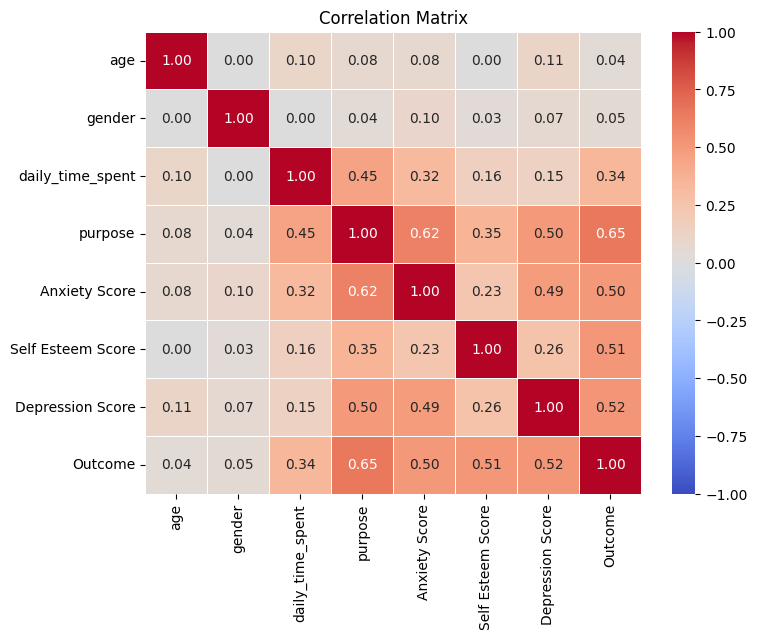

In [62]:
corr = df[['age', 'gender', 'daily_time_spent', 'purpose', 'Anxiety Score', 'Self Esteem Score', 'Depression Score', 'Outcome']].corr()

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f', linewidths=0.5)

# Display the heatmap
plt.title('Correlation Matrix')
plt.show()

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
standardizer = StandardScaler()

In [64]:
X = df.drop(['Outcome'], axis = 1)
y = df['Outcome']
X_scaled = standardizer.fit_transform(X)
X_scaled_train, X_scaled_test, y_train, y_test = train_test_split(X_scaled, y , test_size=0.20,random_state=6)

In [65]:
X.isnull().sum()

,0
age,0
gender,0
daily_time_spent,0
purpose,0
Anxiety Score,0
Self Esteem Score,0
Depression Score,0


In [66]:
smote = SMOTE(sampling_strategy='auto', random_state=42)


X_train_resampled, y_train_resampled = smote.fit_resample(X_scaled_train, y_train)


print("Class distribution after SMOTE: ")
print(pd.Series(y_train_resampled).value_counts())

Class distribution after SMOTE: 
Outcome
0    592
1    592
2    592
Name: count, dtype: int64


In [67]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [68]:
classifiers = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Support Vector Machine": SVC(),
    "Naive Bayes": GaussianNB(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(),

}


In [69]:
results = {}
for name, clf in classifiers.items():
    clf.fit(X_train_resampled, y_train_resampled )
    y_pred = clf.predict(X_scaled_test)
    accuracy = accuracy_score(y_test, y_pred)*100
    results[name] = accuracy
    print(f"{name} Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    print('-' * 50)

Logistic Regression Accuracy: 98.5075
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       151
           1       0.98      0.96      0.97        46
           2       0.75      0.75      0.75         4

    accuracy                           0.99       201
   macro avg       0.91      0.90      0.90       201
weighted avg       0.98      0.99      0.99       201

[[151   0   0]
 [  1  44   1]
 [  0   1   3]]
--------------------------------------------------
Decision Tree Accuracy: 95.0249
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       151
           1       0.91      0.87      0.89        46
           2       1.00      0.75      0.86         4

    accuracy                           0.95       201
   macro avg       0.96      0.87      0.91       201
weighted avg       0.95      0.95      0.95       201

[[148   3   0]
 [  6  40   0]
 [  0   1   3]]
-------------------------

In [70]:
results_df = pd.DataFrame(list(results.items()), columns=['Classifier', 'Accuracy'])
print("\nComparison of Classifier Accuracies:")
print(results_df)


Comparison of Classifier Accuracies:
               Classifier   Accuracy
0     Logistic Regression  98.507463
1           Decision Tree  95.024876
2           Random Forest  96.517413
3  Support Vector Machine  97.014925
4             Naive Bayes  86.069652
5     K-Nearest Neighbors  91.044776
6       Gradient Boosting  96.517413
7                 XGBoost  95.522388


In [71]:

for name, clf in classifiers.items():
    clf.fit(X_train_resampled, y_train_resampled)
    y_train_pred = clf.predict(X_scaled_train)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    print(f"{name} - Training Accuracy: {train_accuracy:.4f}")
    print(f"{name} - Test Accuracy: {results[name]:.4f}")


Logistic Regression - Training Accuracy: 0.9962
Logistic Regression - Test Accuracy: 98.5075
Decision Tree - Training Accuracy: 1.0000
Decision Tree - Test Accuracy: 95.0249
Random Forest - Training Accuracy: 1.0000
Random Forest - Test Accuracy: 96.5174
Support Vector Machine - Training Accuracy: 0.9938
Support Vector Machine - Test Accuracy: 97.0149
Naive Bayes - Training Accuracy: 0.8675
Naive Bayes - Test Accuracy: 86.0697
K-Nearest Neighbors - Training Accuracy: 0.9525
K-Nearest Neighbors - Test Accuracy: 91.0448
Gradient Boosting - Training Accuracy: 1.0000
Gradient Boosting - Test Accuracy: 96.5174
XGBoost - Training Accuracy: 1.0000
XGBoost - Test Accuracy: 95.5224


In [72]:
from sklearn.model_selection import cross_val_score

for name, clf in classifiers.items():
    scores = cross_val_score(clf, X_train_resampled, y_train_resampled, cv=5)  # 5-fold cross-validation
    print(f"{name} - 5-Fold Cross-Validation Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

Logistic Regression - 5-Fold Cross-Validation Accuracy: 0.9944 ± 0.0025
Decision Tree - 5-Fold Cross-Validation Accuracy: 0.9567 ± 0.0193
Random Forest - 5-Fold Cross-Validation Accuracy: 0.9887 ± 0.0079
Support Vector Machine - 5-Fold Cross-Validation Accuracy: 0.9916 ± 0.0040
Naive Bayes - 5-Fold Cross-Validation Accuracy: 0.9054 ± 0.0123
K-Nearest Neighbors - 5-Fold Cross-Validation Accuracy: 0.9662 ± 0.0069
Gradient Boosting - 5-Fold Cross-Validation Accuracy: 0.9882 ± 0.0082
XGBoost - 5-Fold Cross-Validation Accuracy: 0.9865 ± 0.0074


<Figure size 600x500 with 0 Axes>

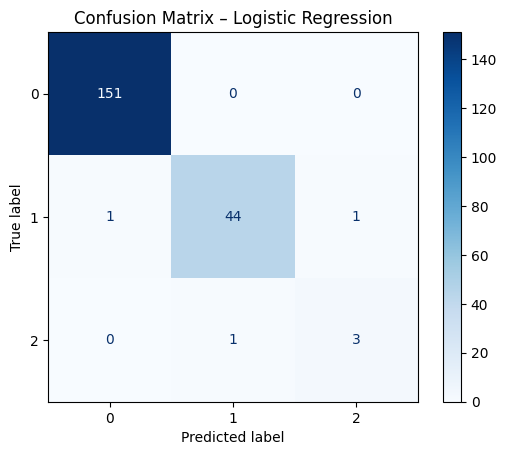

In [73]:
from sklearn.metrics import ConfusionMatrixDisplay

best_model = LogisticRegression()
best_model.fit(X_train_resampled, y_train_resampled)
y_pred = best_model.predict(X_scaled_test)

plt.figure(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    cmap="Blues",
    normalize=None
)
plt.title("Confusion Matrix – Logistic Regression")
plt.show()


In [74]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_accuracies = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_scaled, y), start=1):
    X_train_f, X_val_f = X_scaled[train_idx], X_scaled[val_idx]
    y_train_f, y_val_f = y.iloc[train_idx], y.iloc[val_idx]

    # ✅ SMOTE only on the fold's training data
    smote = SMOTE(random_state=42, k_neighbors=1)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_f, y_train_f)

    model = LogisticRegression(max_iter=2000)
    model.fit(X_train_resampled, y_train_resampled)

    y_val_pred = model.predict(X_val_f)
    acc = accuracy_score(y_val_f, y_val_pred)
    fold_accuracies.append(acc)

print("Fold accuracies:", fold_accuracies)
print(f"Mean ± std: {np.mean(fold_accuracies):.4f} ± {np.std(fold_accuracies):.4f}")




Fold accuracies: [0.9701492537313433, 1.0, 0.99, 0.99, 0.985]
Mean ± std: 0.9870 ± 0.0097


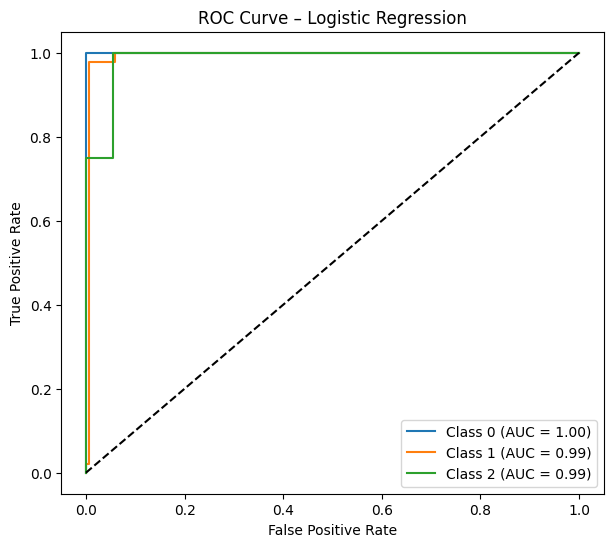

In [75]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0,1,2])
y_score = best_model.predict_proba(X_scaled_test)

plt.figure(figsize=(7,6))
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Logistic Regression")
plt.legend()
plt.show()


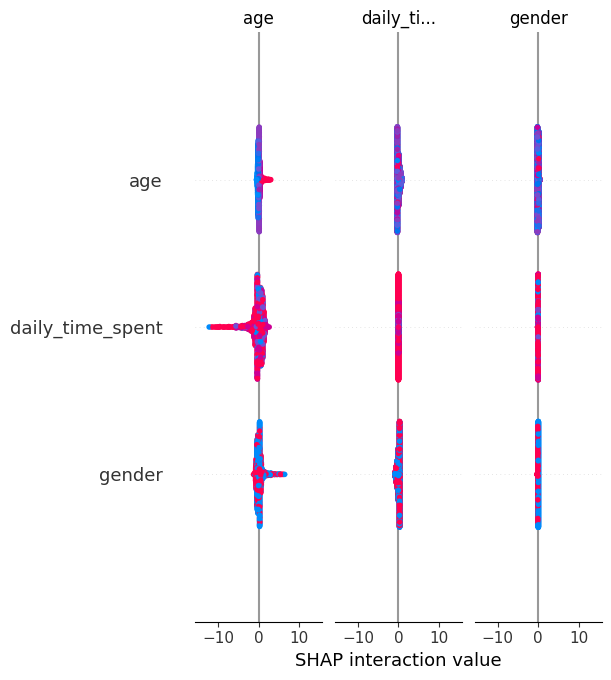

In [76]:
import shap

explainer = shap.LinearExplainer(best_model, X_train_resampled)
shap_values = explainer.shap_values(X_train_resampled)

shap.summary_plot(
    shap_values,
    X_train_resampled,
    feature_names=X.columns
)


In [77]:
!pip -q install lime


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [78]:
from lime.lime_tabular import LimeTabularExplainer

explainer = LimeTabularExplainer(
    X_train_resampled,
    feature_names=X.columns,
    class_names=["No", "Mild", "Moderate"],
    mode="classification"
)

i = 0  # choose any test instance
exp = explainer.explain_instance(
    X_scaled_test[i],
    best_model.predict_proba,
    num_features=8
)

exp.show_in_notebook()
import joblib

joblib.dump(best_model, "best_model.pkl")
joblib.dump(standardizer, "scaler.pkl")


['scaler.pkl']